In [9]:
!pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 26.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from fairlearn.metrics import (
    MetricFrame,
    selection_rate, false_positive_rate, false_negative_rate,
    equalized_odds_difference, demographic_parity_difference
)

# Load and clean
df = pd.read_csv('compas-scores-two-years.csv')
df = df[
    (df['days_b_screening_arrest'] >= -30) &
    (df['days_b_screening_arrest'] <= 30) &
    (df['is_recid'] != -1) &
    (df['c_charge_degree'] != 'O') &
    (df['score_text'] != 'N/A')
]
df['two_year_recid'] = df['two_year_recid'].astype(int)
df['race'] = df['race'].replace({'African-American': 'Black', 'Caucasian': 'White'})
df = df[df['race'].isin(['Black', 'White'])]

# Features and target
features = ['age', 'sex', 'priors_count', 'c_charge_degree',
            'juv_fel_count', 'juv_misd_count', 'juv_other_count']
X = pd.get_dummies(df[features], drop_first=True)
y = df['two_year_recid']
race = df['race'].reset_index(drop=True)

# Split
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race, test_size=0.3, random_state=42
)

# Train model (no race)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Fairness audit
metrics = {
    'Accuracy': accuracy_score,
    'Selection Rate': selection_rate,
    'False Positive Rate': false_positive_rate,
    'False Negative Rate': false_negative_rate
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=race_test
)

print("=== Fairness Metrics by Race ===")
print(metric_frame.by_group)
print("\n=== Overall Metrics ===")
print(metric_frame.overall)

=== Fairness Metrics by Race ===
       Accuracy  Selection Rate  False Positive Rate  False Negative Rate
race                                                                     
Black  0.669772        0.458592             0.284810             0.373984
White  0.674757        0.258900             0.157333             0.584362

=== Overall Metrics ===
Accuracy               0.671717
Selection Rate         0.380682
False Positive Rate    0.228504
False Negative Rate    0.443537
dtype: float64


In [9]:
import matplotlib.pyplot as plt
# Fairness metric calculations
eq_odds_diff = equalized_odds_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=race_test
)
demo_parity_diff = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=race_test
)

print(f"Equalized Odds Difference: {eq_odds_diff:.3f}")
print(f"Demographic Parity Difference: {demo_parity_diff:.3f}")

Equalized Odds Difference: 0.210
Demographic Parity Difference: 0.200


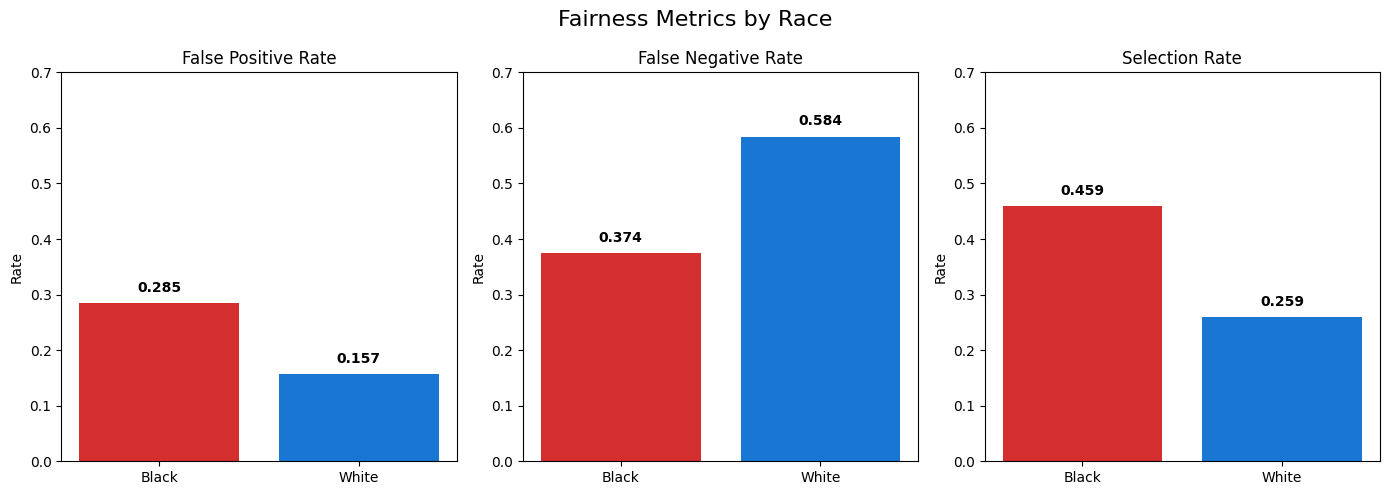

In [10]:
# Prepare data for plotting
metrics_by_race = metric_frame.by_group
metrics_names = ['False Positive Rate', 'False Negative Rate', 'Selection Rate']

# Create side-by-side bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(metrics_names):
    ax = axes[i]
    values = metrics_by_race[metric]
    ax.bar(['Black', 'White'], values, color=['#d32f2f', '#1976d2'])
    ax.set_title(metric)
    ax.set_ylim(0, 0.7)
    ax.set_ylabel('Rate')
    # Add value labels on bars
    for j, v in enumerate(values):
        ax.text(j, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Fairness Metrics by Race', fontsize=16)
plt.tight_layout()
plt.show()